<a href="https://colab.research.google.com/github/mugalan/moodle-quiz-creation/blob/main/Moodle_Ai_Quiz_creation_API_Cookbook_Public.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Instructions

This notebook sets up an environment to interact with an external API to save and create MOODLE MCQ quizzes.

1. You can create your quizzes using the following openAI GPT

      [Mugas Quiz Creator GPT](https://chatgpt.com/g/g-687de661eb948191805df6aaa5c1acf5-mcq-quiz-generator)

2. Specify the topic, the number of questions and the level (ex: Undergraduate Sophoomore) and the GPT will give you a structured output that you have simply copy and paste in the cell block blow **Step 2 - Assign the GPT output to the varaible records**.

3. Create moodle quiz xml

4. Save xml to file

5. Download from files and upload to moodle



#Initialization

In [1]:
!pip install xmltodict

In [2]:
import copy
import xmltodict
import ast
def create_moodle_quiz(questionsdict):
    """
    Create a Moodle multichoice quiz XML payload from a list of question dictionaries.

    This function converts a sequence of question specifications into a Moodle-compatible

    XML quiz string using ``xmltodict.unparse``. Each input question is expected to define

    the question name, grade, question text, one correct answer, and any number of

    incorrect answer choices. The generated quiz uses Moodle's ``multichoice`` question

    type with a single correct answer and shuffled choices.

    Parameters

    ----------

    questionsdict : list of dict

        A list where each element is a dictionary describing one multiple-choice question.

        Each dictionary must contain at least the following keys:

        - ``"name"`` : str

            The question name used internally in Moodle.

        - ``"grade"`` : str or int or float

            The default grade assigned to the question.

        - ``"question"`` : str

            The question text shown to the student.

        - ``"correct"`` : str

            The correct answer choice.

        Any additional keys with non-empty values are treated as incorrect answer choices.

    Returns

    -------

    dict

        A dictionary with the following structure:

        - ``"status"`` : str

            Returns ``"success"`` when the XML is generated.

        - ``"response"`` : dict

            Contains:



            - ``"meta_data"`` : str

                A short status description.

            - ``"xml"`` : str

                The generated Moodle quiz XML as a string.

            - ``"message"`` : str

                A human-readable success message.

    Notes

    -----

    - The generated questions are of Moodle type ``multichoice``.

    - Only one answer is marked as correct.

    - Answers are shuffled in Moodle.

    - Empty or ``None`` answer values are skipped.

    - This function mutates the input dictionaries by removing the keys

      ``"name"``, ``"grade"``, and ``"question"`` using ``pop()``.

    Examples

    --------

    >>> questions = [

    ...     {

    ...         "name": "Q1",

    ...         "grade": "1",

    ...         "question": "What is 2 + 2?",

    ...         "correct": "4",

    ...         "wrong1": "3",

    ...         "wrong2": "5",

    ...         "wrong3": "6"

    ...     }

    ... ]

    >>> result = create_moodle_quiz(questions)

    >>> result["status"]

    'success'

    >>> "xml" in result["response"]

    True

    """
    answerdict={'@fraction': '0',
                '@format': 'html',
                'text': '<p dir="ltr" style="text-align: left;">Choice<br></p>',
                'feedback': {'@format': 'html', 'text': 'none'}}
    questionict={'@type': 'multichoice',
                'name': {'text': 'Quation Name1'},
                'questiontext': {'@format': 'html','text': '<p dir="ltr" style="text-align: left;"></p><p>Text 1<p></p>'},
                'generalfeedback': {'@format': 'html', 'text': 'none'},
                'defaultgrade': '1',
                'penalty': '0',
                'hidden': '0',
                'idnumber': 'none',
                'single': 'true',
                'shuffleanswers': 'true',
                'answernumbering': 'none',
                'showstandardinstruction': '0',
                'correctfeedback': {'@format': 'html', 'text': 'Your answer is correct.'},
                'partiallycorrectfeedback': {'@format': 'html',
                'text': 'Your answer is partially correct.'},
                'incorrectfeedback': {'@format': 'html', 'text': 'Your answer is incorrect.'},
                'shownumcorrect': 'none',
                'answer': [answerdict]}
    xml_dict={'quiz':{'question':[questionict]}}
    question=[]
    for dct in questionsdict:
        qdct=copy.deepcopy(questionict)
        qdct['name']['text']=dct['name']
        dct.pop('name')
        qdct['defaultgrade']=dct['grade']
        dct.pop('grade')
        qdct['questiontext']['text']= '<p dir="ltr" style="text-align: left;"></p><p>{}<p></p>'.format(dct['question'])
        dct.pop('question')
        answer=[]
        for ky in [*dct]:
            adct=copy.deepcopy(answerdict)
            if dct[ky] not in ['',None]:
                if ky=='correct':
                    adct['@fraction']='100'
                    adct['text']='<p dir="ltr" style="text-align: left;">{}<br></p>'.format(dct[ky])
                else:
                    adct['@fraction']='0'
                    adct['text']='<p dir="ltr" style="text-align: left;">{}<br></p>'.format(dct[ky])
                answer+=[adct]
                qdct['answer']=answer
        question+=[qdct]
    xml_dict={'quiz':{'question':question}}
    xml_data = xmltodict.unparse(xml_dict, pretty=True)
    status='success'
    message="Moodle XML quiz generated"
    meta_data=message
    response = {"meta_data": meta_data, "xml":xml_data, "message":message}
    return {"status": status, "response": response}

def save_quiz_xml(filename='quiz', xml_content=''):
    if xml_content:
        with open(f'{filename}.xml', 'w', encoding='utf-8') as f:
            f.write(xml_content)
        print(f"XML content saved to {filename}.xml")
    else:
        print("No XML content found to save.")

#Moodle Quiz Creation

## Step 1 - Create the quiz data using the openAI GPT

Create your moodle quiz by following the link to the customized GPT below. It produces the quiz in a JSON fromat of a list of dictionaries.

https://chatgpt.com/g/g-687de661eb948191805df6aaa5c1acf5-mcq-quiz-generator

## Step 2 - Assign the GPT output to the varaible records

Copy and paste the structured output of the GPT and assign it to the variable records as shown in the example below:

###Example screenshot

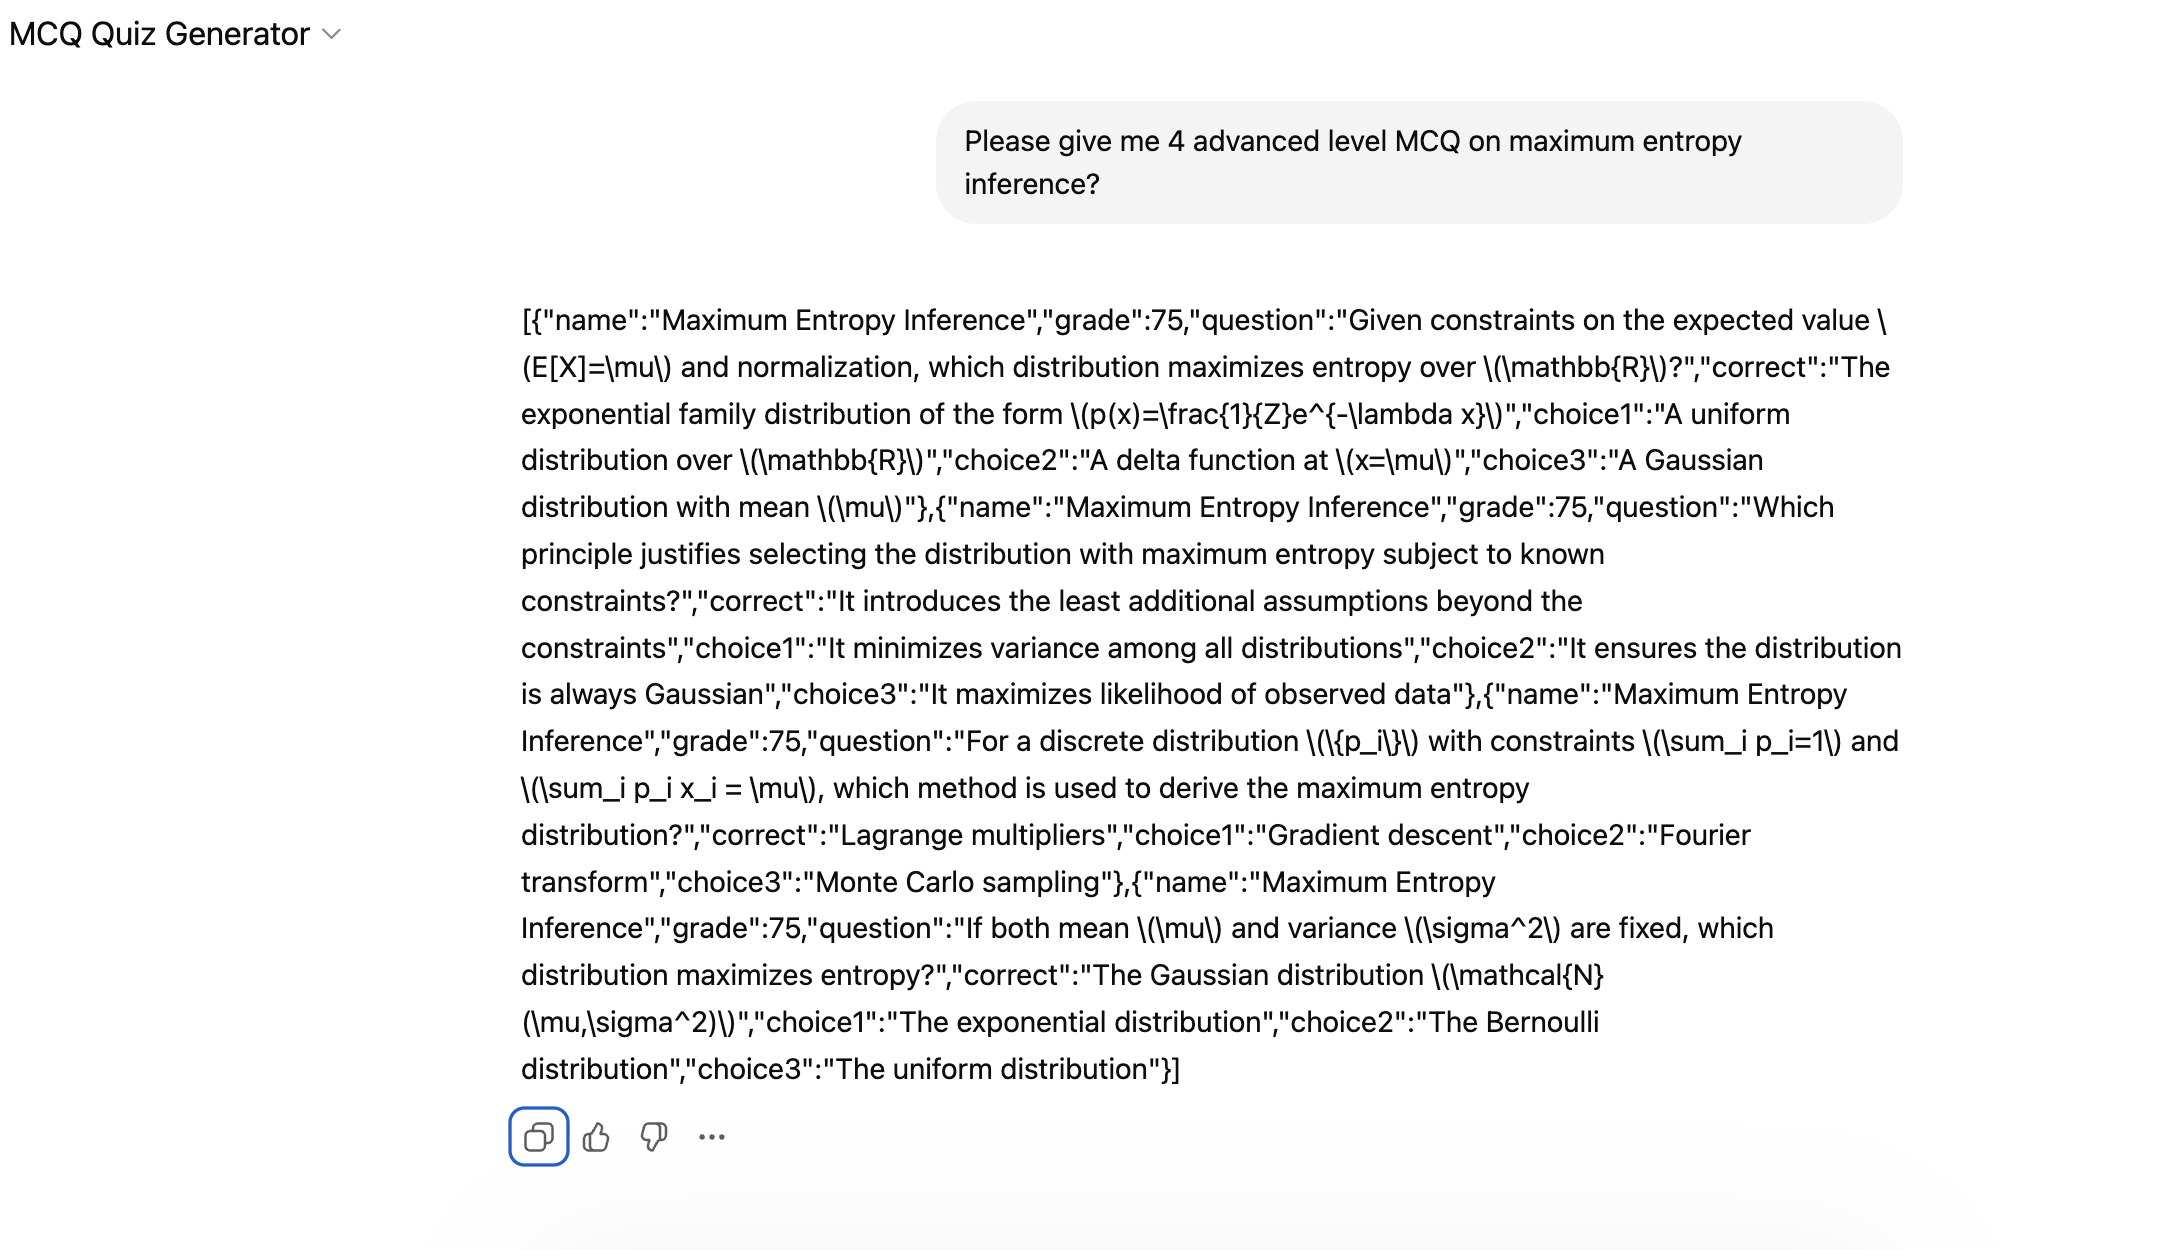

### Create the Questiobs Dictionary

In [13]:
raw_text=r'''
[{"name":"Maximum Entropy Inference","grade":75,"question":"Given constraints on the expected value \(E[X]=\mu\) and normalization, which distribution maximizes entropy over \(\mathbb{R}\)?","correct":"The exponential family distribution of the form \(p(x)=\frac{1}{Z}e^{-\lambda x}\)","choice1":"A uniform distribution over \(\mathbb{R}\)","choice2":"A delta function at \(x=\mu\)","choice3":"A Gaussian distribution with mean \(\mu\)"},{"name":"Maximum Entropy Inference","grade":75,"question":"Which principle justifies selecting the distribution with maximum entropy subject to known constraints?","correct":"It introduces the least additional assumptions beyond the constraints","choice1":"It minimizes variance among all distributions","choice2":"It ensures the distribution is always Gaussian","choice3":"It maximizes likelihood of observed data"},{"name":"Maximum Entropy Inference","grade":75,"question":"For a discrete distribution \(\{p_i\}\) with constraints \(\sum_i p_i=1\) and \(\sum_i p_i x_i = \mu\), which method is used to derive the maximum entropy distribution?","correct":"Lagrange multipliers","choice1":"Gradient descent","choice2":"Fourier transform","choice3":"Monte Carlo sampling"},{"name":"Maximum Entropy Inference","grade":75,"question":"If both mean \(\mu\) and variance \(\sigma^2\) are fixed, which distribution maximizes entropy?","correct":"The Gaussian distribution \(\mathcal{N}(\mu,\sigma^2)\)","choice1":"The exponential distribution","choice2":"The Bernoulli distribution","choice3":"The uniform distribution"}]
''' #Replace PASTE_YOUR_COPIED_TEXT_HERE with the text you have copied from ChatGPT
safe_text = raw_text.replace("\\", "\\\\")
questionsdict = ast.literal_eval(safe_text)

print(questionsdict[0]["question"])

Given constraints on the expected value \(E[X]=\mu\) and normalization, which distribution maximizes entropy over \(\mathbb{R}\)?


## Step 3 - Create Moodle Quiz xml

If you are happy with the create run the code below to create the moodle quiz.

In [14]:
response = create_moodle_quiz(questionsdict)
print(f"Response status: {response.get('status','error')}")
print(f"Response message: {response.get('response',{}).get('message','error')}")

Response status: success
Response message: Moodle XML quiz generated


## Step 4 - Save Quiz to file

In [15]:
xml_content=response.get('response',{}).get('xml','')
save_quiz_xml(filename='quiz_32',xml_content=xml_content)

XML content saved to quiz_32.xml


In [ ]:
xml_content